<img src="logo-UNSAM.png" style="float: right;" width="300" alt="Logo">

# <center>Análisis y Procesamiento de Señales</center>
<hr>

## <center>**TS7**: "Filtrado digital lineal de ECG"</center>

<br><br>

### <center>1er Cuatrimestre - 2026</center>
### <center>**Alumno:** D'Alesio Alejo</center>


<br>

En este trabajo vamos a analizar un registro electrocardiográfico (ECG) registrado durante una prueba de esfuerzo que contiene fuentes de contaminación como:
* Ruido causado por el movimiento de los electrodos (Alta frecuencia)
* Ruido muscular (Alta frecuencia)
* Movimiento de la línea de base del ECG, inducido en parte por la respiración (Baja frecuencia) 

El objetivo del trabajo sera diseñar y aplicar los filtros necesarios para mitigar dichas fuentes de contaminación.

## Filtros IIR

Para el diseño de la plantilla del filtro digital, se deben especificar dos frecuencias de paso (wp1, wp2), dos frecuencias de stop (ws1, ws2), la atenuación máxima en banda de paso (gpass) y la atenuación mínima en banda de stop (gstop).
A partir del análisis espectral (PSD) de la señal de ECG, se observó que la energía útil de la señal se concentra entre wp1 = 0.5 Hz y wp2 = 35 Hz.
La frecuencia de stop inferior la fijamos en ws1 = 0.1 Hz.
La frecuencia de stop superior la fijamos en ws2 = 45 Hz.
La atenuación en banda de paso, por dato, se fija en gpass = 1 dB. La atenuación mínima en banda de stop se fija en gstop = 40 dB, lo que significa reducir el ruido a 1/100 de su amplitud original, suficiente dado el nivel de ruido observado en el espectro de la señal.

Vamos a diseñar tres filtros digitales IIR adoptando las aproximaciones de modulo de maxima planicidad, Chebyshev y Cauer

C:\Users\aleej\AppData\Local\Temp\ipykernel_10592\2342513910.py:47: RuntimeWarning: divide by zero encountered in log10
  db_butter = 20 * np.log10(np.abs(h_butter))


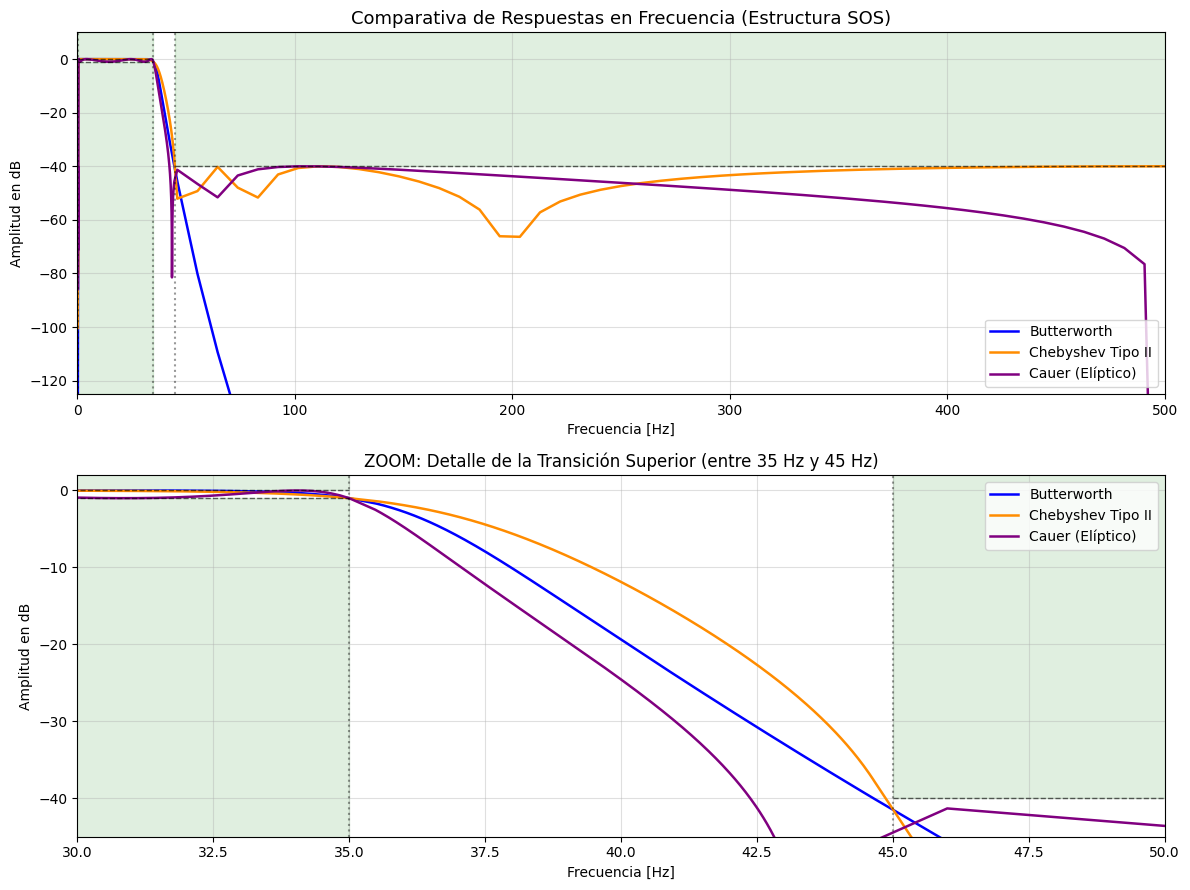

In [33]:
"""
@author: alejo
"""

#%% Librerías
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import signal as sig
import scipy.io as sio

#%%  Módulo en veces y Fase desenvuelta
fs = 1000      # Frecuencia de muestreo en Hz

gpass = 1     # Atenuación máxima permitida en banda de paso (dB)
gstop = 40    # Atenuación mínima requerida en banda de stop (dB)

# Para un filtro pasa banda (diseno de plantilla)
ws1 = 0.1
wp1 = 0.5 
ws2 = 45
wp2 = 35

wp = [wp1, wp2]
ws = [ws1, ws2] 

###################################
####### GRILLA PERSONALIZADA #######
###################################
# Se usa np.concatenate para asegurar compatibilidad en entornos estándar
ww = np.concatenate([np.logspace(start = -2, stop = 0.1, num = 500), 
                     np.linspace(start = 1.26, stop = 35, num = 200), 
                     np.logspace(start = 1.55, stop = 1.65, num = 300),
                     np.linspace(start = 46, stop = fs//2, num = 50)])

# Respuesta en frecuencia - Diseños de los 3 filtros
sos_butter = sig.iirdesign(wp, ws, gpass, gstop, fs=fs, analog=False, ftype='butter', output='sos')
sos_cheby  = sig.iirdesign(wp, ws, gpass, gstop, fs=fs, analog=False, ftype='cheby2', output='sos')
sos_cauer  = sig.iirdesign(wp, ws, gpass, gstop, fs=fs, analog=False, ftype='cauer', output='sos')

# Evaluamos la respuesta en frecuencia para cada uno
w, h_butter = sig.sosfreqz(sos_butter, worN=ww, fs=fs)
_, h_cheby  = sig.sosfreqz(sos_cheby, worN=ww, fs=fs)
_, h_cauer  = sig.sosfreqz(sos_cauer, worN=ww, fs=fs)

# Convertimos las magnitudes a dB
db_butter = 20 * np.log10(np.abs(h_butter))
db_cheby  = 20 * np.log10(np.abs(h_cheby))
db_cauer  = 20 * np.log10(np.abs(h_cauer))

# =============================================================================
# BLOQUE DE PLOTS: VISTA GENERAL Y ZOOM SUPERIOR (3 FILTROS)
# =============================================================================
fig, (ax_main, ax_zoom) = plt.subplots(2, 1, figsize=(12, 9), tight_layout=True)

# Seteamos un piso y techo visuales para el gráfico
piso_grafico = -125
techo_grafico = 10

for ax in [ax_main, ax_zoom]:
    # 1. Graficar las tres curvas con distintos colores
    ax.plot(w, db_butter, color='blue', linewidth=1.8, label='Butterworth')
    ax.plot(w, db_cheby, color='darkorange', linewidth=1.8, label='Chebyshev Tipo II')
    ax.plot(w, db_cauer, color='purple', linewidth=1.8, label='Cauer (Elíptico)')
    
    # 2. Sombreado de la Plantilla (Zonas prohibidas)
    # --- Banda de parada 1 (0 a ws1) ---
    ax.fill_between([0, ws1], -gstop, techo_grafico, color='green', alpha=0.12)
    ax.plot([0, ws1], [-gstop, -gstop], 'k--', linewidth=1, alpha=0.6)
    
    # --- Banda de paso (wp1 a wp2) ---
    # Zona inferior
    ax.fill_between([wp1, wp2], piso_grafico, -gpass, color='green', alpha=0.12)
    ax.plot([wp1, wp2], [-gpass, -gpass], 'k--', linewidth=1, alpha=0.6)
    # Zona superior (Ajustada a 0 dB para coherencia matemática de filtros normalizados)
    ax.fill_between([wp1, wp2], 0, techo_grafico, color='green', alpha=0.12) 
    ax.plot([wp1, wp2], [0, 0], 'k--', linewidth=1, alpha=0.6)
    
    # --- Banda de parada 2 (ws2 a Nyquist) ---
    ax.fill_between([ws2, fs/2], -gstop, techo_grafico, color='green', alpha=0.12)
    ax.plot([ws2, fs/2], [-gstop, -gstop], 'k--', linewidth=1, alpha=0.6)
    
    # Líneas verticales indicadoras de frecuencias de corte
    for freq in [ws1, wp1, wp2, ws2]:
        ax.axvline(freq, color='k', linestyle=':', alpha=0.4)
        
    ax.grid(True, which='both', linestyle='-', alpha=0.4)

# =============================================================================
# CONFIGURACIÓN DE LÍMITES Y EJES INDIVIDUALES
# =============================================================================

# Configuración del Gráfico General (Arriba)
ax_main.set_title("Comparativa de Respuestas en Frecuencia (Estructura SOS)", fontsize=13)
ax_main.set_ylabel('Amplitud en dB')
ax_main.set_xlabel('Frecuencia [Hz]')
ax_main.set_xlim(0, fs/2)
ax_main.set_ylim([piso_grafico, techo_grafico])
ax_main.legend(loc='lower right')

# Configuración del Zoom de Alta Frecuencia (Abajo: wp2 a ws2)
ax_zoom.set_title(f"ZOOM: Detalle de la Transición Superior (entre {wp2} Hz y {ws2} Hz)", fontsize=12)
ax_zoom.set_ylabel('Amplitud en dB')
ax_zoom.set_xlabel('Frecuencia [Hz]')

# Ajustamos los límites para ver la caída desde 0dB hasta cruzar los -40dB (gstop)
ax_zoom.set_xlim(30, 50)
ax_zoom.set_ylim([-45, 2]) 
ax_zoom.legend(loc='upper right')

plt.show()

In [34]:
# Calcular el orden teórico mínimo que requiere cada filtro para tu plantilla
orden_butt, _  = sig.buttord(wp, ws, gpass, gstop, fs=fs)
orden_cheby, _ = sig.cheb2ord(wp, ws, gpass, gstop, fs=fs)
orden_cauer, _ = sig.ellipord(wp, ws, gpass, gstop, fs=fs)

print(f"Orden real Butterworth:  {2*orden_butt}  (Secciones SOS: {sos_butter.shape[0]})")
print(f"Orden real Chebyshev II: {2*orden_cheby}  (Secciones SOS: {sos_cheby.shape[0]})")
print(f"Orden real Cauer:        {2*orden_cauer}  (Secciones SOS: {sos_cauer.shape[0]})")

Orden real Butterworth:  42  (Secciones SOS: 21)
Orden real Chebyshev II: 16  (Secciones SOS: 8)
Orden real Cauer:        10  (Secciones SOS: 5)


Observamos que los tres filtros IIR cumplen con los limites impuestos por la plantilla de diseño, tanto en la banda de paso como en las bandas de stop. Para el caso de Butterworth, vemos que es el de mayor orden, lo que obliga a usar mas polos para alcanzar la atenuación requerida en la banda de stop. Esto se traduce en mayor complejidad computacional. Luego, tenemos Chebyshev que tiene un orden intermedio, lo que da mas libertad para caer que el Butterworth con menos polos. Por último, tenemos el caso del Cauer que tiene el menor orden, siendo el que tiene menor complejidad computacional. 

Ahora, analizamos y procesamos la señal del ECG con ruido utilizando los filtros que diseñamos.

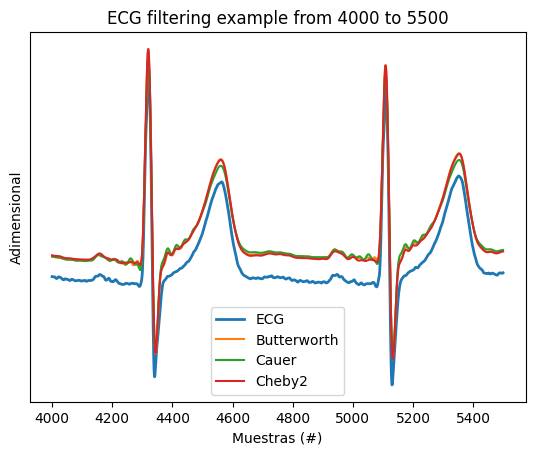

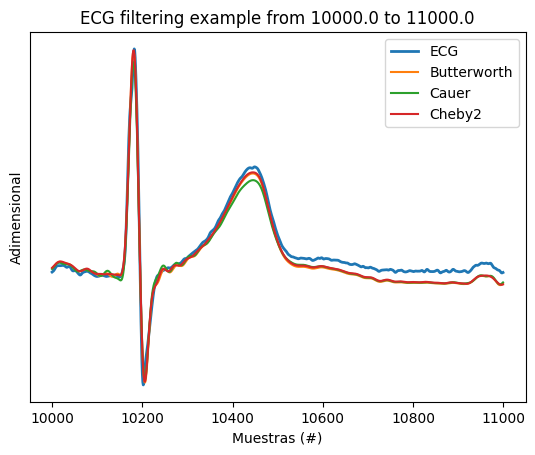

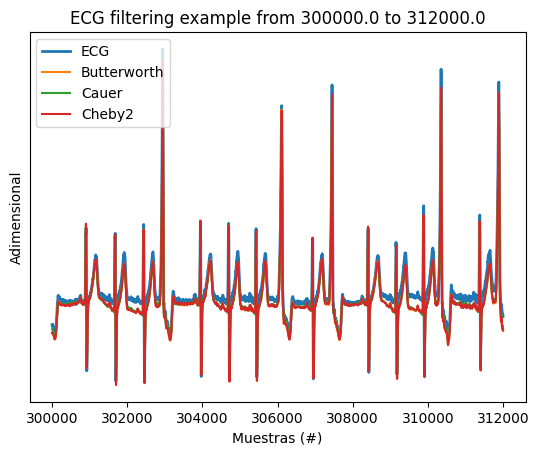

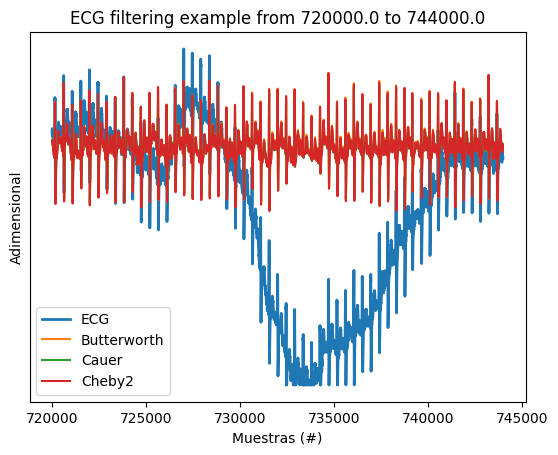

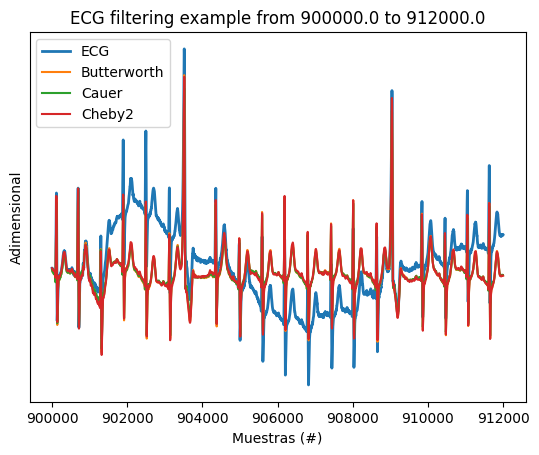

In [35]:
#uso filtfilt entonces divido por dos gpass y gstop 

sos_ff_butter = sig.iirdesign(wp, ws, gpass/2, gstop/2, fs=fs, analog=False, ftype='butter', output='sos')
sos_ff_cheby  = sig.iirdesign(wp, ws, gpass/2, gstop/2, fs=fs, analog=False, ftype='cheby2', output='sos')
sos_ff_cauer  = sig.iirdesign(wp, ws, gpass/2, gstop/2, fs=fs, analog=False, ftype='cauer', output='sos')

mat_struct = sio.loadmat(r'pdstestbench/ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead'].flatten() #lo aplanamos
cant_muestras = len(ecg_one_lead)

#Procesar ecg

yy = sig.sosfilt(sos, ecg_one_lead)
ECG_f_butt = sig.sosfiltfilt(sos_ff_butt, ecg_one_lead)
ECG_f_cauer = sig.sosfiltfilt(sos_ff_cauer, ecg_one_lead)
ECG_f_cheby2 = sig.sosfiltfilt(sos_ff_cheby, ecg_one_lead)

###################################
#%% Regiones de interés sin ruido #
###################################
 
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth')
    plt.plot(zoom_region, ECG_f_cauer[zoom_region], label='Cauer')
    plt.plot(zoom_region, ECG_f_cheby2[zoom_region], label='Cheby2')
    #plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()
 
###################################
#%% Regiones de interés con ruido #
###################################
 
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth')
    plt.plot(zoom_region, ECG_f_cauer[zoom_region], label='Cauer')
    plt.plot(zoom_region, ECG_f_cheby2[zoom_region], label='Cheby2')
    #plt.plot(zoom_region, ECG_f_butt[zoom_region], label='')
    #plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

Al aplicar los filtros mediante sosfiltfilt se observa que los tres diseños logran reducir el ruido de alta frecuencia mejorando la suavidad de los trazos, cumpliendo así con los objetivos planteados en el diseño de la plantilla. Asimismo, se destaca la excelente capacidad de los tres diseños para eliminar la deriva de la línea de base visible en la señal original (entre las muestras 730.000 y 740.000). Al remover estas bajas frecuencias no deseadas, los filtros logran estabilizar y centrar la señal en el eje vertical sin distorsionar la morfología de los complejos QRS.

Considerando la relación entre calidad de filtrado y complejidad computacional, el filtro Cauer resulta el más conveniente: logra la misma calidad que el Butterworth con un orden menor, siendo por tanto más eficiente.

## Filtros FIR

Ahora vamos a diseñar los filtros FIR, manteniendo los limites impuestos anteriormente en el filtro IIR

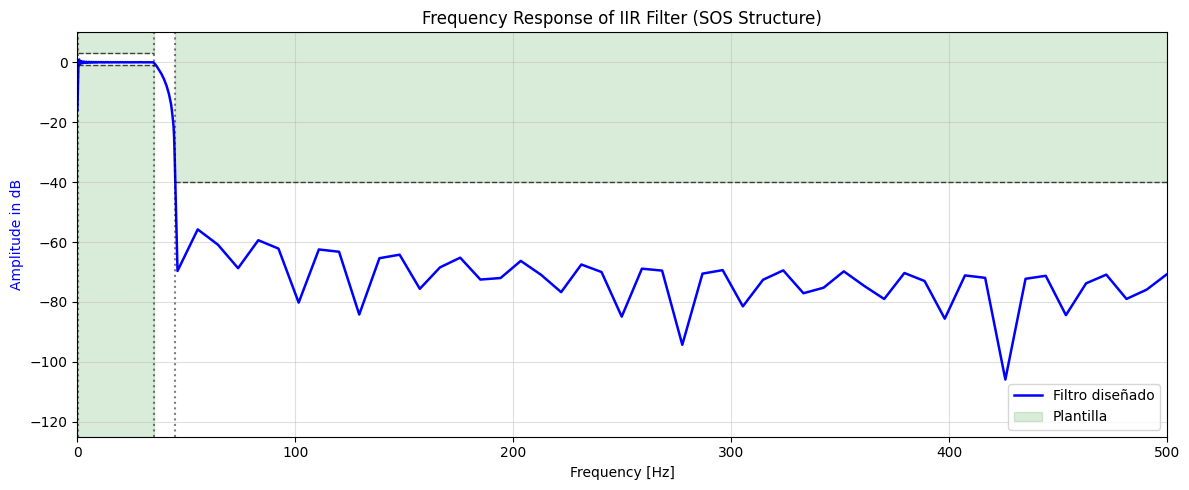

In [2]:
# -*- coding: utf-8 -*-
"""
Created on Wed Jun  3 17:40:14 2026

@author: alejo
"""

#%% Librerías
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import signal as sig
import scipy.io as sio


#%%  Módulo en veces y Fase desenvuelta
fs = 1000      # Frecuencia de muestreo en Hz

gpass = 1     # Atenuación máxima permitida en banda de paso (dB)
gstop = 40    # Atenuación mínima requerida en banda de stop (dB)

# Para un filtro pasa banda (diseno de plantilla)
ws1 = 0.1
wp1 = 0.5 
ws2 = 45
wp2 = 35

wp = [wp1, wp2]
ws = [ws1, ws2] 


###################################
#######GRILLA PERSONALIZADA########
###################################

ww = np.concat([np.logspace(start = -2,stop = 0.1, num = 500), 
               np.linspace(start=1.26,stop = 35, num = 200), 
               np.logspace(start = 1.55,stop = 1.65, num = 300),
               np.linspace(start=46,stop = fs//2, num = 50)])

#%% DISEÑO DE FIRS

#numero bajo de taps(busco que sea mas alto que los IIR)

numtaps = 1801 #es tipo 2, cantidad de coef par, el retardo es no entero

demora = (numtaps - 1 ) //2 #division entera

#Esi numtaps = 1801 nos aseguramos el retardo entero 1801-1/2

gains = np.array([0 ,0,1,1,0,0])

#FILTRO FIR METODOLOGIA DE VENTANAS

b_win = sig.firwin2(numtaps,freq=np.array([0.,ws1,wp1,wp2,ws2,fs//2]),  #usamos Boxcar 
                            gain= gains,window = 'boxcar',
                            fs=fs)
w,h = sig.freqz(b_win,worN = ww, fs = fs)

# =============================================================================
# BLOQUE DE PLOT CON PLANTILLA DE DISEÑO (SOMBRADA)
# =============================================================================

fig, ax1 = plt.subplots(figsize=(12, 5), tight_layout=True)
ax1.set_title("Frequency Response of IIR Filter (SOS Structure)")

# 1. Dibujar la curva del filtro original (Magnitud en dB)
ax1.plot(w, 20 * np.log10(np.abs(h)), 'b', linewidth=1.8, label='Filtro diseñado')

# 2. Sombreado de la Plantilla (Zonas prohibidas / tolerancias)
# Piso y techo visual del gráfico para los rellenos
piso_grafico = -125
techo_grafico = 10

# --- Banda de parada 1 (0 a ws1) ---
ax1.fill_between([0, ws1], -gstop, techo_grafico, color='green', alpha=0.15, label='Plantilla')
ax1.plot([0, ws1], [-gstop, -gstop], 'k--', linewidth=1, alpha=0.7) # Línea de trazo límite

# --- Banda de paso (wp1 a wp2) ---
# Zona inferior (Atenuación máxima permitida)
ax1.fill_between([wp1, wp2], piso_grafico, -gpass, color='green', alpha=0.15)
ax1.plot([wp1, wp2], [-gpass, -gpass], 'k--', linewidth=1, alpha=0.7)
# Zona superior (Margen por encima de 0dB, ej: 3dB para evitar rizado excesivo)
ax1.fill_between([wp1, wp2], 3, techo_grafico, color='green', alpha=0.15)
ax1.plot([wp1, wp2], [3, 3], 'k--', linewidth=1, alpha=0.7)

# --- Banda de parada 2 (ws2 a Nyquist) ---
ax1.fill_between([ws2, fs/2], -gstop, techo_grafico, color='green', alpha=0.15)
ax1.plot([ws2, fs/2], [-gstop, -gstop], 'k--', linewidth=1, alpha=0.7)

# Líneas verticales que delimitan los saltos de las bandas
ax1.axvline(ws1, color='k', linestyle=':', alpha=0.5)
ax1.axvline(wp1, color='k', linestyle=':', alpha=0.5)
ax1.axvline(wp2, color='k', linestyle=':', alpha=0.5)
ax1.axvline(ws2, color='k', linestyle=':', alpha=0.5)

# 3. Configuración estricta de límites y estética
ax1.set_ylabel('Amplitude in dB', color='b')
ax1.set_xlabel('Frequency [Hz]')
ax1.set_xlim(0, fs/2)
ax1.set_ylim([piso_grafico, techo_grafico]) 

ax1.grid(True, which='both', linestyle='-', alpha=0.4)
ax1.legend(loc='lower right')

plt.show()

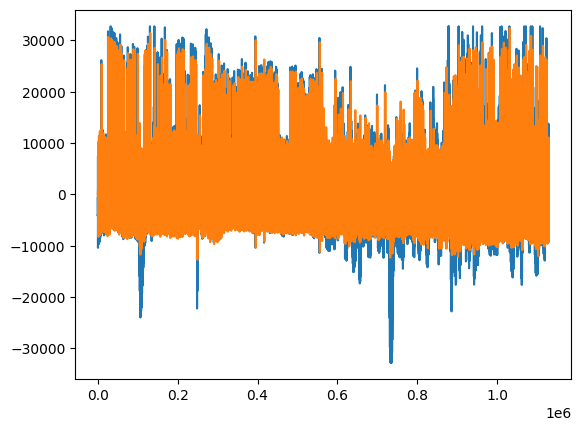

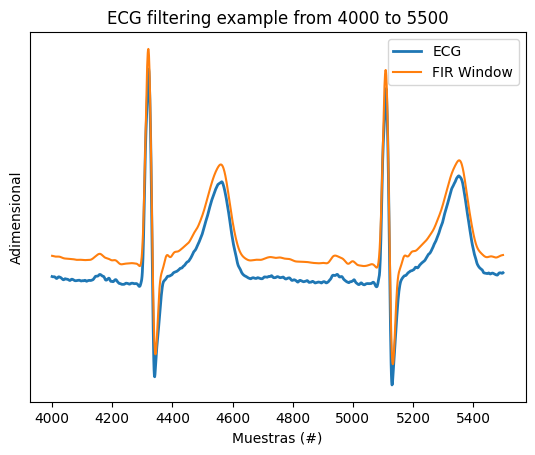

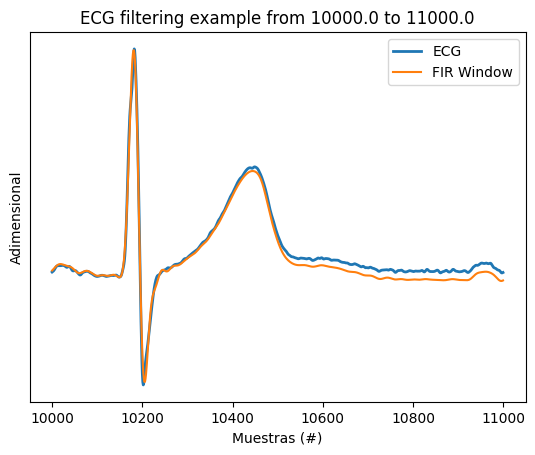

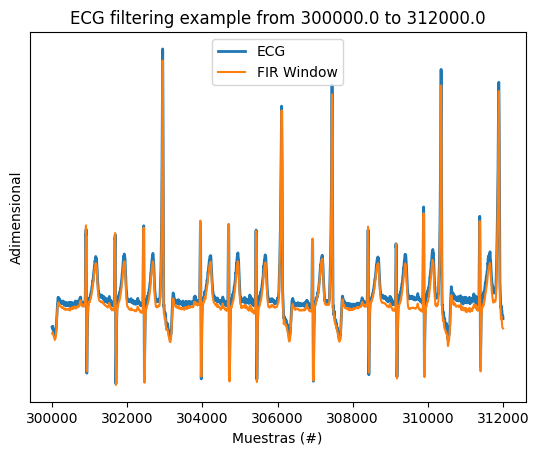

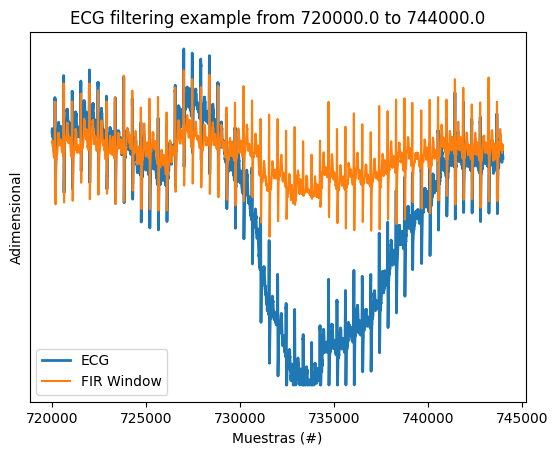

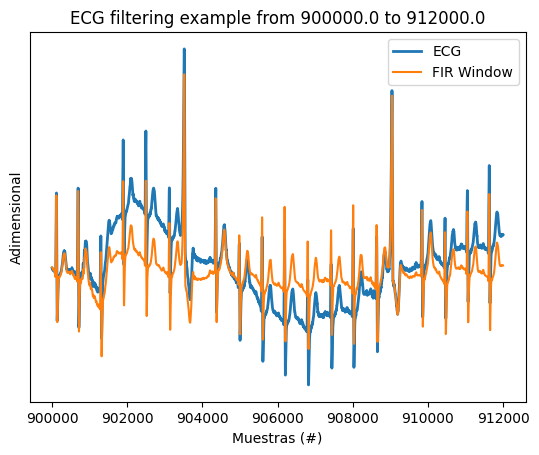

In [5]:


##################
## ECG con ruido
##################

mat_struct = sio.loadmat(r'pdstestbench/ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead'].flatten() #lo aplanamos
cant_muestras = len(ecg_one_lead)

#Procesar ecg

ECG_f_win = sig.lfilter(b_win,1., ecg_one_lead)


b_win
plt.figure()
plt.plot(ecg_one_lead)
plt.plot(ECG_f_win)

###################################
#%% Regiones de interés sin ruido #
###################################
 
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()
 
###################################
#%% Regiones de interés con ruido #
###################################
 
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()